In [3]:
import jax
import jax.numpy as jnp

print("JAX Devices:", jax.devices())

# GPU 연산 테스트
x = jnp.ones((1000, 1000))
y = jnp.ones((1000, 1000))
result = jnp.dot(x, y).block_until_ready()

print("연산 완료!")

JAX Devices: [cuda(id=0)]
연산 완료!


JAX Devices: [cuda(id=0)]
Running window adaptation


Only one chain was sampled, this makes it impossible to run some convergence checks


샘플링 시간: 6.43 초


array([[<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

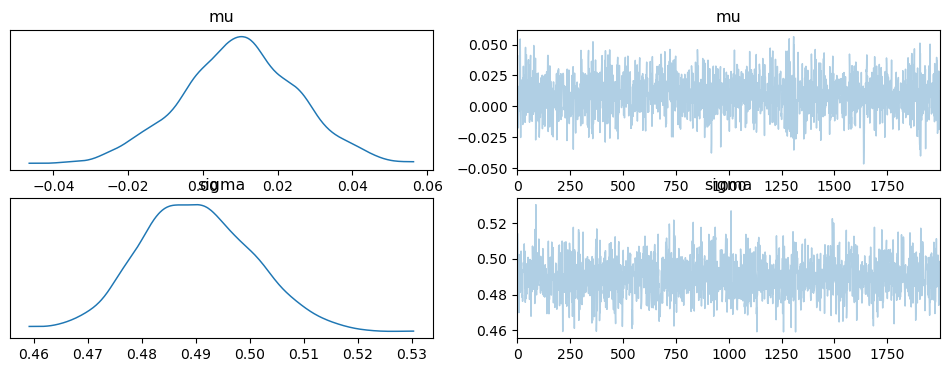

In [8]:
import pymc as pm
import numpy as np
import arviz as az
import time

print("JAX Devices:", jax.devices())

# 데이터 생성
np.random.seed(42)
n_samples = 1000
true_mu = 0.0
true_sigma = 0.5
data = np.random.normal(true_mu, true_sigma, size=n_samples)

# 모델 정의
with pm.Model() as model:
    # 사전분포 정의
    mu = pm.Normal("mu", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # 관측 모델
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=data)

    # 샘플링 시작 시간
    start_time = time.time()

    # JAX 백엔드로 NUTS 샘플링
    trace = pm.sample(
        2000, 
        tune=1000, 
        target_accept=0.9, 
        chains=1, 
        cores=1,
        nuts_sampler="blackjax",  # JAX 백엔드 지정
        random_seed=42,
        progressbar=True
    )

    # 샘플링 종료 시간
    elapsed_time = time.time() - start_time
    print(f"샘플링 시간: {elapsed_time:.2f} 초")

# 결과 시각화
az.plot_trace(trace)